# What this notebook contains using AWS S3 + SageMaker

This end-to-end notebook walks through everything one needs to build, tune, register and inspect a churn-prediction model entirely in SageMaker while using Amazon S3 as the single source of truth for data and artifacts following this [post](https://aws.amazon.com/blogs/machine-learning/build-tune-and-deploy-an-end-to-end-churn-prediction-model-using-amazon-sagemaker-pipelines/).

1. **Data ingestion & preprocessing**

Raw customer-behaviour data provided from [Kaggle](https://www.kaggle.com/uttamp/store-data) are pulled from S3, cleaned and feature-engineered with a SKLearnProcessor.

The resulting dataset is split into train/validation/test CSVs and the feature-name list; all splits are written back to S3 for repeatable experiments.

2. **Pipelines-based ML workflow**

A SageMaker Pipeline stitches the process together:

ProcessingStep: executes the preprocessing script.

TuningStep: launches a hyper-parameter tuning job that explores an XGBoost search space (eta, max_depth, etc.) and automatically selects the best model by AUC on the validation set.

ModelStep/Register: creates a reusable SageMaker model from the winning artifact and, after an AUC quality gate, registers it in Model Registry with its evaluation metrics attached.

TransformStep: runs an offline/batch transform job so one can score a large CSV in S3 without deploying an endpoint.

3. **Model explainability**

A Clarify post-processing job generates SHAP value plots and a bias report that are versioned per pipeline run and stored in S3 for audit.

4. **Operational extras**

Demonstrates how to diagnose and fix two common blockers: VPC endpoint connectivity for Studio and missing IAM permissions for the execution role.

Shows how to pull down the best model, compute SHAP values locally and visualise feature impact.

When one runs the notebook start-to-finish, they end up with: clean datasets in S3, a reproducible SageMaker Pipeline, a tuned and registered XGBoost churn model, explainability reports, and a template one can adapt to other tabular ML problems all orchestrated with managed SageMaker services and nothing stored on local disks.

# Operational extras:

Earlier, the pipeline kept failing at pipeline.upsert() with "An AWS IAM role is required ..." or "AccessDenied" messages because the execution role SageMaker was using did not have every permission the pipeline steps needed (for example it could launch training jobs but not create a ProcessingJob, register a model package, or pass itself to the Clarify and Batch-Transform services). To fix this I:

1. Identified the role in use with sagemaker.get_execution_role() and noted its ARN.

2. In the IAM console I attached the AWS-managed policies AmazonSageMakerFullAccess and AmazonS3FullAccess (or, more securely, bucket-scoped S3 permissions).

3. Added an inline policy that allows the extra calls the blog workflow makes principally sagemaker:CreateModelPackage, sagemaker:CreateModelPackageGroup, sagemaker:DescribeProcessingJob, sagemaker:CreateTags, and iam:PassRole on the role itself.

4. Edited the role's trust relationship so the principal list includes sagemaker.amazonaws.com, clarify.amazonaws.com, and batch-transform.amazonaws.com, allowing SageMaker to assume the role on behalf of those managed services.

5. Passed that role explicitly everywhere the SDK asked for it (e.g., pipeline.upsert(role_arn=role) and in every processor/transformer/clarify constructor).

After these changes the pipeline could create processing and tuning jobs, register the best model, spin up Batch Transform and Clarify runs, and complete end-to-end without any IAM-related errors.

For example, often times I would have to do

1. IAM --> Roles --> search for datazone_usr_role_cjtse5at5xzhrd_5fgsappn13fig9.
2. Add permissions --> Attach policies.
3. Tick AmazonS3ReadOnlyAccess and Add permissions.

That AWS-managed policy grants s3:ListBucket and s3:GetObject on every bucket in my account for my work using SageMaker.

I also had some virtual private cloud (VPC) issues that were resolved and explained nicely in this video [End-to-end Churn Prediction with Amazon SageMaker Pipelines](https://www.youtube.com/watch?v=OUv8F5vUPk4&ab_channel=DataMastery). Here are some sample pictures during the process

### 1. Network-connectivity issue (now resolved). The banner appeared because my SageMaker Studio domain was in a subnet that couldn’t reach key VPC interface endpoints (sagemaker.api, sagemaker.runtime, sts). Moving the domain to a private subnet with a NAT gateway or adding the missing endpoints restored connectivity and the warning vanished.

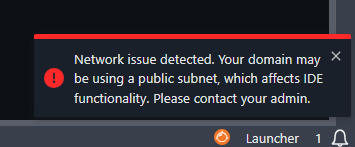

---

### 2. IAM permissions issue (now resolved). Processing, training and tuning jobs initially failed with AccessDenied / UnauthorizedOperationerrors because the execution role datazone_usr_role_cjtse5at5xzhrd_5fgsappn13fig9lacked the required SageMaker and S3 permissions.  Attaching the AWS-managed policies  AmazonS3ReadOnlyAccess, SageMakerStudioBedrockKnowledgeBaseServiceRolePolicy,SageMakerStudioProjectRoleMachineLearningPolicy, andSageMakerStudioProjectUserRolePolicy cleared the errors.

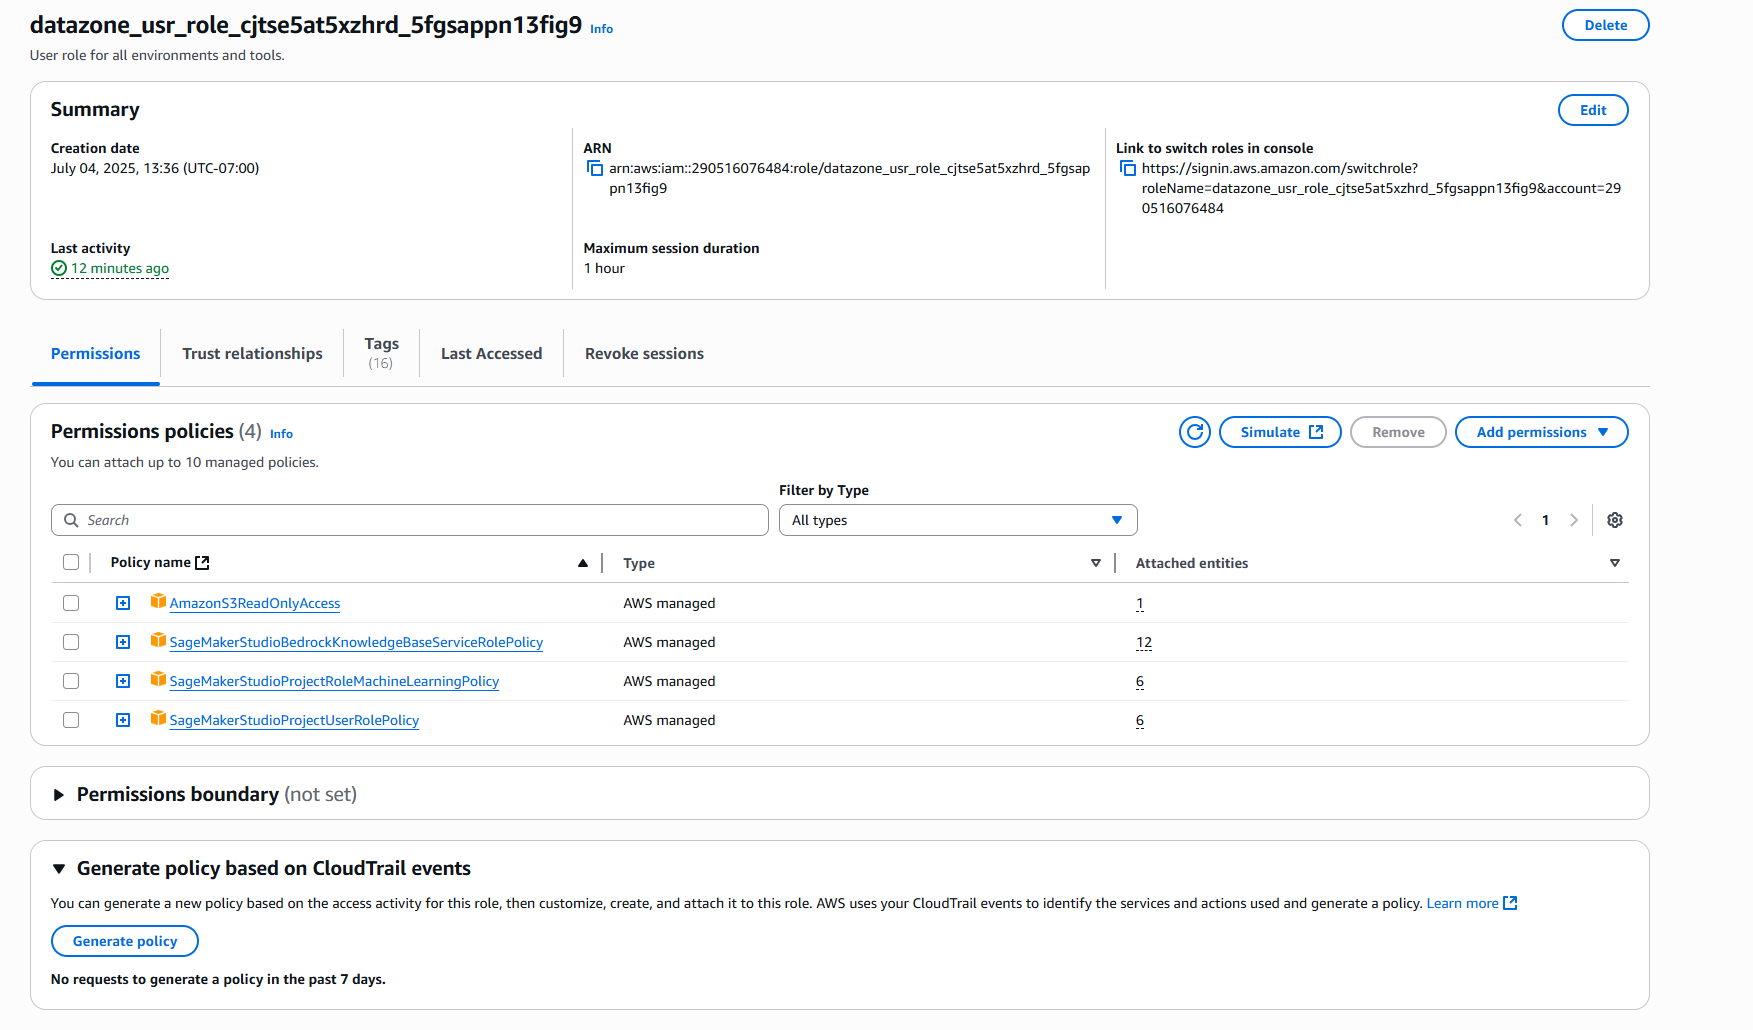

---

In [17]:
from IPython.display import Image, Markdown, display

screenshots = [
    (
        "1. Network-connectivity issue (now resolved). "
        "The banner appeared because my SageMaker Studio domain was in a subnet that "
        "couldn’t reach key VPC interface endpoints (sagemaker.api, sagemaker.runtime, sts). "
        "Moving the domain to a private subnet with a NAT gateway or adding the missing "
        "endpoints restored connectivity and the warning vanished.",
        r"C:\Users\steph\OneDrive\Desktop\9d33e4fd-232d-4009-8e09-ffaa8b526a54.png",
    ),

    (
        "2. IAM permissions issue (now resolved). " 
        "Processing, training and tuning jobs initially failed with AccessDenied / UnauthorizedOperation"
        "errors because the execution role datazone_usr_role_cjtse5at5xzhrd_5fgsappn13fig9"
        "lacked the required SageMaker and S3 permissions.  "
        "Attaching the AWS-managed policies  "
        "AmazonS3ReadOnlyAccess, SageMakerStudioBedrockKnowledgeBaseServiceRolePolicy,"
        "SageMakerStudioProjectRoleMachineLearningPolicy, and"
        "SageMakerStudioProjectUserRolePolicy cleared the errors.",
        r"C:\Users\steph\OneDrive\Desktop\64e8e1e8-463c-48d4-b8c7-1ed3394701fa.png",
    ),
]

for caption, img_path in screenshots:
    display(Markdown(f"### {caption}"))
    display(Image(filename=img_path))
    display(Markdown("---"))



# We can see that everything is up and running smoothly in AWS SageMaker

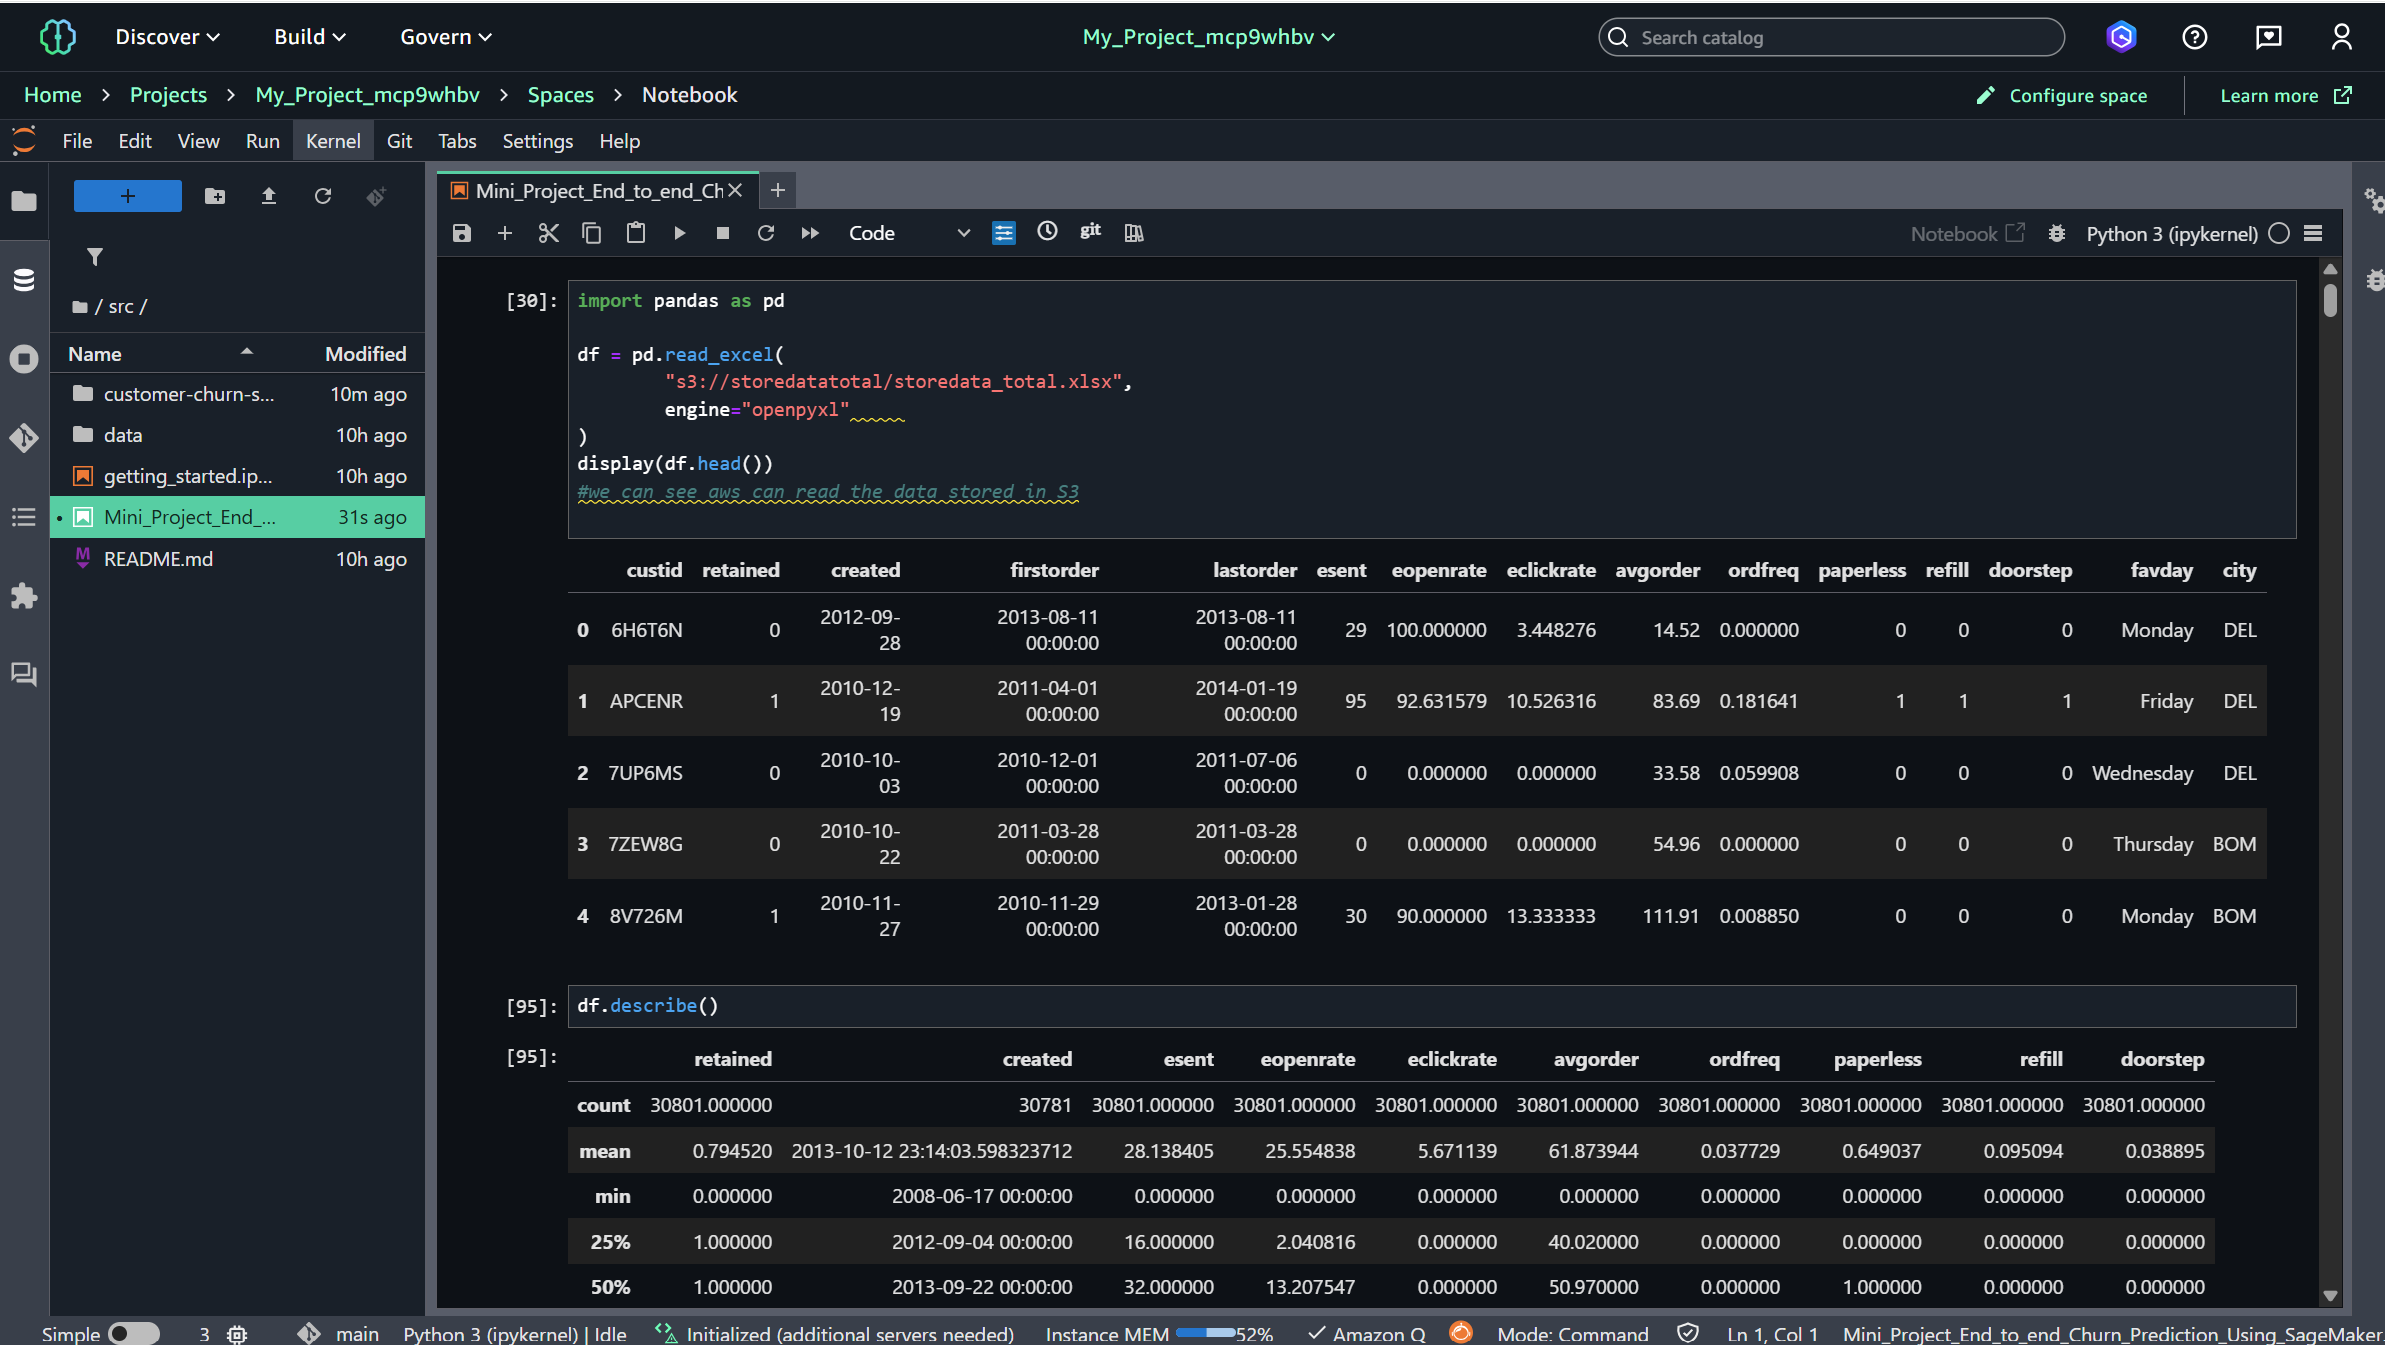

In [18]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\steph\OneDrive\Desktop\Screenshot 2025-07-05 024522.png"))


In [30]:
import pandas as pd

df = pd.read_excel(
        "s3://storedatatotal/storedata_total.xlsx",
        engine="openpyxl"     
)
display(df.head())
#we can see aws can read the data stored in S3


,custid,retained,created,firstorder,lastorder,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,refill,doorstep,favday,city
0,6H6T6N,0,2012-09-28,2013-08-11 00:00:00,2013-08-11 00:00:00,29,100.000000,3.448276,14.52,0.000000,0,0,0,Monday,DEL
1,APCENR,1,2010-12-19,2011-04-01 00:00:00,2014-01-19 00:00:00,95,92.631579,10.526316,83.69,0.181641,1,1,1,Friday,DEL
2,7UP6MS,0,2010-10-03,2010-12-01 00:00:00,2011-07-06 00:00:00,0,0.000000,0.000000,33.58,0.059908,0,0,0,Wednesday,DEL
3,7ZEW8G,0,2010-10-22,2011-03-28 00:00:00,2011-03-28 00:00:00,0,0.000000,0.000000,54.96,0.000000,0,0,0,Thursday,BOM
4,8V726M,1,2010-11-27,2010-11-29 00:00:00,2013-01-28 00:00:00,30,90.000000,13.333333,111.91,0.008850,0,0,0,Monday,BOM


In [95]:
df.describe()

,retained,created,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,refill,doorstep
count,30801.000000,30781,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000
mean,0.794520,2013-10-12 23:14:03.598323712,28.138405,25.554838,5.671139,61.873944,0.037729,0.649037,0.095094,0.038895
min,0.000000,2008-06-17 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2012-09-04 00:00:00,16.000000,2.040816,0.000000,40.020000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2013-09-22 00:00:00,32.000000,13.207547,0.000000,50.970000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,2013-12-16 00:00:00,42.000000,40.000000,7.142857,74.280000,0.040816,1.000000,0.000000,0.000000
max,1.000000,2018-01-17 00:00:00,291.000000,100.000000,100.000000,2600.140000,3.250000,1.000000,1.000000,1.000000
std,0.404059,NaN,16.751380,29.557106,10.561704,41.007588,0.103932,0.477279,0.293350,0.193347


#  Step 0 a: Verify Studio is up

In [15]:
import sagemaker, boto3, os

region = boto3.Session().region_name
sess   = sagemaker.Session()
role   = sagemaker.get_execution_role()

print("Region:", region)
print("Execution role:", role)

default_bucket = sess.default_bucket()
print("Default bucket:", default_bucket)


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Region: us-east-2
Execution role: arn:aws:iam::290516076484:role/datazone_usr_role_cjtse5at5xzhrd_5fgsappn13fig9
Default bucket: amazon-sagemaker-290516076484-us-east-2-6ebac09d703c


# Step 0 b: clone the sample project

In [16]:
!git clone https://github.com/aws-samples/customer-churn-sagemaker-pipelines-sample.git
%cd customer-churn-sagemaker-pipelines-sample

fatal: destination path 'customer-churn-sagemaker-pipelines-sample' already exists and is not an empty directory.
/home/sagemaker-user/src/customer-churn-sagemaker-pipelines-sample


# Setp 0 c: Create a data/ folder inside the repo

In [17]:
!mkdir -p data
!ls -l 

total 932
-rw-r--r-- 1 sagemaker-user users    309 Jul  4 21:16 CODE_OF_CONDUCT.md
-rw-r--r-- 1 sagemaker-user users   3160 Jul  4 21:16 CONTRIBUTING.md
-rw-r--r-- 1 sagemaker-user users 904145 Jul  4 22:50 Customer_Churn_Modeling.ipynb
-rw-r--r-- 1 sagemaker-user users    927 Jul  4 21:16 LICENSE
-rw-r--r-- 1 sagemaker-user users   3388 Jul  4 21:16 README.md
-rw-r--r-- 1 sagemaker-user users  30559 Jul  4 22:50 SageMaker_Pipelines_project.ipynb
drwxr-xr-x 7 sagemaker-user users    236 Jul  4 22:11 customer-churn-sagemaker-pipelines-sample
drwxr-xr-x 2 sagemaker-user users     70 Jul  4 21:59 data
drwxr-xr-x 2 sagemaker-user users     58 Jul  4 21:16 img
drwxr-xr-x 3 sagemaker-user users     27 Jul  4 21:16 pipelines


# Step 0 d: pull Excel from my own S3 bucket, convert to CSV, push to default bucket

In [18]:
# 1. the helper libs are available
!pip install -q --upgrade "s3fs>=2023.1" openpyxl         

import pandas as pd, sagemaker, boto3, pathlib, os, io

# 2️. Read the Excel workbook straight from S3
excel_uri = "s3://storedatatotal/storedata_total.xlsx"    # bucket/key
df = pd.read_excel(excel_uri, engine="openpyxl")          # pandas uses s3fs behind the scenes

print(f"Loaded {len(df):,} rows from Excel")
display(df.head())

# 3️. Save a local CSV copy inside the repo (data/storedata_total.csv)
data_dir  = pathlib.Path("data");  data_dir.mkdir(exist_ok=True)
local_csv = data_dir / "storedata_total.csv"
df.to_csv(local_csv, index=False)
print("Local CSV written to", local_csv.resolve())

# 4️. Upload the CSV to **default SageMaker bucket** so every pipeline step can read it
sess      = sagemaker.Session()
bucket    = sess.default_bucket()                         # e.g. amazon-sagemaker-123456789012-us-east-2
key       = "data/storedata_total.csv"

sess.upload_data(str(local_csv), bucket=bucket, key_prefix="data")
print(f"Uploaded: s3://{bucket}/{key}")

# 5. sanity-check
!aws s3 ls s3://{bucket}/data/



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-ai 2.31.4 requires faiss-cpu!=1.8.0.post0,<2.0.0,>=1.8.0, which is not installed.
jupyter-scheduler 2.10.0 requires fsspec<=2024.10.0,>=2023.6.0, but you have fsspec 2025.5.1 which is incompatible.
Loaded 30,801 rows from Excel


,custid,retained,created,firstorder,lastorder,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,refill,doorstep,favday,city
0,6H6T6N,0,2012-09-28,2013-08-11 00:00:00,2013-08-11 00:00:00,29,100.000000,3.448276,14.52,0.000000,0,0,0,Monday,DEL
1,APCENR,1,2010-12-19,2011-04-01 00:00:00,2014-01-19 00:00:00,95,92.631579,10.526316,83.69,0.181641,1,1,1,Friday,DEL
2,7UP6MS,0,2010-10-03,2010-12-01 00:00:00,2011-07-06 00:00:00,0,0.000000,0.000000,33.58,0.059908,0,0,0,Wednesday,DEL
3,7ZEW8G,0,2010-10-22,2011-03-28 00:00:00,2011-03-28 00:00:00,0,0.000000,0.000000,54.96,0.000000,0,0,0,Thursday,BOM
4,8V726M,1,2010-11-27,2010-11-29 00:00:00,2013-01-28 00:00:00,30,90.000000,13.333333,111.91,0.008850,0,0,0,Monday,BOM


Local CSV written to /home/sagemaker-user/src/customer-churn-sagemaker-pipelines-sample/data/storedata_total.csv
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Uploaded: s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/data/storedata_total.csv
                           PRE test/
                           PRE train/
                           PRE validation/
2025-07-04 22:39:48        257 feature_names.csv
2025-07-05 06:16:20    3394535 storedata_total.csv


# Following instructions

# End-to-End S3 Data Preprocessing: Clean, Feature-Engineer, and Re-Upload CSV

This notebook cell installs an up-to-date S3 file-system library and then walks through a full "download, clean, and re-upload" data-prep loop in Amazon SageMaker. First it grabs the current SageMaker session, IAM execution role, and default S3 bucket, and builds two S3 paths: one for the raw CSV (data/storedata_total.csv) and one for the cleaned version it will create (processed/storedata_total_preprocessed.csv). A preprocess_data function is defined to read the raw file with Pandas, parse three date columns, drop any rows with missing values, engineer two new "days-difference" features, remove unneeded columns, and one-hot-encode the categorical columns favday and city. The function is executed on the raw S3 URI, producing a cleaned DataFrame called storedata, whose shape is printed so one can confirm the transformation. The cleaned data is then written to a local data/ folder and immediately uploaded back to the same S3 bucket under the processed/ prefix. Finally, an AWS CLI command lists the contents of that processed folder so one can visually verify that the new pre-processed file is now stored in S3 and ready for the next steps in this ML pipeline.

In [19]:
!pip install -q --upgrade "s3fs>=2023.1"  

import pandas as pd, boto3, sagemaker, pathlib, io, os

# 1) Where are we reading from / writing to?
sess            = sagemaker.Session()
default_bucket  = sess.default_bucket()                       # e.g. amazon-sagemaker-123...us-east-2
raw_key         = "data/storedata_total.csv"
proc_key        = "processed/storedata_total_preprocessed.csv"

raw_uri  = f"s3://{default_bucket}/{raw_key}"
proc_uri = f"s3://{default_bucket}/{proc_key}"

print("Raw  CSV ", raw_uri)
print("Proc CSV ", proc_uri)

# 2) preprocessing function
def preprocess_data(file_path):
    df = pd.read_csv(file_path)                               

    # original logic
    df["firstorder"]  = pd.to_datetime(df["firstorder"], errors="coerce")
    df["lastorder"]   = pd.to_datetime(df["lastorder"],  errors="coerce")
    df = df.dropna()
    df["first_last_days_diff"]   = (df["lastorder"] - df["firstorder"]).dt.days
    df["created"] = pd.to_datetime(df["created"])
    df["created_first_days_diff"] = (df["created"] - df["firstorder"]).dt.days
    df.drop(["custid","created","firstorder","lastorder"], axis=1, inplace=True)
    df = pd.get_dummies(df, prefix=["favday","city"], columns=["favday","city"])
    return df

# 3) Run preprocessing
df_proc = preprocess_data(raw_uri)
storedata = df_proc 
print("Preprocessed shape:", df_proc.shape)

# 4) Save locally & upload back to S3 
local_out = pathlib.Path("data") / "storedata_total_preprocessed.csv"
local_out.parent.mkdir(exist_ok=True)

df_proc.to_csv(local_out, index=False)
print("Local file written:", local_out)

# upload to S3
sess.upload_data(str(local_out), bucket=default_bucket, key_prefix="processed")
print("Uploaded", proc_uri)

!aws s3 ls s3://{default_bucket}/processed/ | head


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Raw  CSV  s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/data/storedata_total.csv
Proc CSV  s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/processed/storedata_total_preprocessed.csv
Preprocessed shape: (30747, 22)
Local file written: data/storedata_total_preprocessed.csv
Uploaded s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/processed/storedata_total_preprocessed.csv
2025-07-05 06:16:33    3373160 storedata_total_preprocessed.csv


# Produce Train/Validation/Test CSV Splits and Feature List on S3

This script takes the in-memory storedata DataFrame, shuffles it, and slices it into training (70 %), validation (15 %), and test (15 %) sets, then pushes each split and a companion file listing the feature column names to Amazon S3 where SageMaker jobs can consume them. It starts by grabbing the default SageMaker bucket and defining split_datasets, a helper that randomizes the rows, pulls out the target column retained, concatenates the label as the first column, and returns NumPy arrays for the three splits along with the list of feature names. After calling this helper, the script creates a tidy local directory tree (data_splits/train, validation, test), writes each split to a CSV with no headers or index to match XGBoost’s expectations, and uses Session.upload_data to copy those files to logical S3 prefixes such as s3://<bucket>/data/train/train.csv, logging each location. Finally, it saves the feature-name list to feature_names.csv and uploads that as well, ensuring downstream processing and model-explainability steps know the exact order of columns.

In [20]:
#  Split the pre-processed DataFrame (storedata) and push the splits to S3
import numpy as np, pandas as pd, pathlib, sagemaker, json

sess           = sagemaker.Session()
default_bucket = sess.default_bucket()                     # eg. amazon-sagemaker-123…us-east-2
s3_prefix      = "data"                                   

# 1️. Split helper
def split_datasets(df, train_pct=0.70, val_pct=0.15, seed=42):
    """Return feature_names, train, validation, test as numpy arrays."""
    rng = np.random.RandomState(seed)
    shuffled = df.sample(frac=1, random_state=rng).reset_index(drop=True)

    y  = shuffled.pop("retained").to_numpy().reshape(-1, 1)
    X  = shuffled.to_numpy()
    Xy = np.concatenate([y, X], axis=1)                    # y in col 0

    n  = len(Xy)
    train_end = int(train_pct * n)
    val_end   = int((train_pct + val_pct) * n)

    train, validation, test = np.split(Xy, [train_end, val_end])
    return shuffled.columns.tolist(), train, validation, test

# 2️. Run the split 
feature_names, train, validation, test = split_datasets(storedata)

# 3️. Save locally and upload
local_base = pathlib.Path("data_splits")
(local_base / "train").mkdir(parents=True, exist_ok=True)
(local_base / "validation").mkdir(exist_ok=True)
(local_base / "test").mkdir(exist_ok=True)

splits = {
    "train":       train,
    "validation":  validation,
    "test":        test,
}

for name, arr in splits.items():
    local_csv = local_base / name / f"{name}.csv"
    pd.DataFrame(arr).to_csv(local_csv, header=False, index=False)

    s3_uri = sess.upload_data(str(local_csv),
                              bucket=default_bucket,
                              key_prefix=f"{s3_prefix}/{name}")
    print(f"Uploaded {name:10} : {s3_uri}")

# 4️. Save feature names
feat_file = local_base / "feature_names.csv"
pd.Series(feature_names).to_csv(feat_file, header=False, index=False)
sess.upload_data(str(feat_file), bucket=default_bucket, key_prefix=s3_prefix)
print(f"Feature names   :    s3://{default_bucket}/{s3_prefix}/feature_names.csv")


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Uploaded train      : s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/data/train/train.csv
Uploaded validation : s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/data/validation/validation.csv
Uploaded test       : s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/data/test/test.csv
Feature names   :    s3://amazon-sagemaker-290516076484-us-east-2-6ebac09d703c/data/feature_names.csv


# Automated Hyperparameter Tuning of an XGBoost Churn Model with Amazon SageMaker

This code block takes one from raw training data all the way to a fully tuned, best-in-class XGBoost churn model without ever leaving the notebook. It first figures out where it’s running (the AWS region, execution role, and an S3 bucket for temporary files), then points SageMaker at the train and validation CSV files already placed in S3. Using the official XGBoost Docker image, it builds an Estimator with sensible “starter” settings for binary classification, such as using AUC as the evaluation metric and running 100 boosting rounds. It then tells SageMaker to search across four key hyper-parameters: learning-rate (eta), tree depth, and two regularization terms over ten different combinations, two at a time. When tuner.fit() runs, SageMaker spins up those training jobs in the background; because the call uses wait=True, the notebook politely pauses until everything finishes. Finally, it asks SageMaker which training run scored highest on validation AUC, prints that winning job’s ARN, and shows the exact hyper-parameter values that achieved the top score. In one go we’ve trained ten candidate models, identified the best performer (AUC = 0.978 in the example output shown below), and surfaced its settings so one can register or deploy it next.

In [106]:
# 1.  SageMaker session, role, region, and default bucket
import boto3
import sagemaker
from sagemaker.inputs import TrainingInput
from sagemaker.tuner  import (
    HyperparameterTuner,
    ContinuousParameter,
    IntegerParameter,
)

sess   = sagemaker.Session()
role   = sagemaker.get_execution_role()
region = boto3.Session().region_name
bucket = sess.default_bucket()

# 2.  Define the training / validation channels
s3_input_train = TrainingInput(
    s3_data      = f"s3://{bucket}/data/train/",
    content_type = "text/csv",
)
s3_input_validation = TrainingInput(
    s3_data      = f"s3://{bucket}/data/validation/",
    content_type = "text/csv",
)

# 3.  XGBoost estimator with baseline hyper-parameters
image_uri = sagemaker.image_uris.retrieve(
    framework = "xgboost",
    region    = region,
    version   = "1.5-1",          
)

estimator = sagemaker.estimator.Estimator(
    image_uri         = image_uri,
    role              = role,
    instance_count    = 1,
    instance_type     = "ml.m4.xlarge",
    output_path       = f"s3://{bucket}/output",
    sagemaker_session = sess,
)

estimator.set_hyperparameters(
    objective              = "binary:logistic",
    eval_metric            = "auc",
    num_round              = 100,
    rate_drop              = 0.3,
    tweedie_variance_power = 1.4,
)

# 4.  Hyper-parameter search space and tuner
hp_ranges = {
    "eta"              : ContinuousParameter(0.01, 0.5),
    "min_child_weight" : ContinuousParameter(1, 10),
    "alpha"            : ContinuousParameter(0, 2),
    "max_depth"        : IntegerParameter(3, 10),
}

tuner = HyperparameterTuner(
    estimator              = estimator,
    objective_metric_name  = "validation:auc",
    hyperparameter_ranges  = hp_ranges,
    max_jobs               = 10,
    max_parallel_jobs      = 2,
    base_tuning_job_name   = "churn-xgb",
)

# 5.  Launch tuning job and block until completion (wait=True)
tuner.fit(
    inputs={
        "train"      : s3_input_train,
        "validation" : s3_input_validation,
    },
    include_cls_metadata = False,
    wait = True,                 # block; cell returns only when tuning job finishes
)

print("Tuning job completed:", tuner.latest_tuning_job.job_name)

# 6.  Retrieve and display the best training job
sm_client = boto3.client("sagemaker")

tuning_desc = sm_client.describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName = tuner.latest_tuning_job.job_name
)

best_job = tuning_desc.get("BestTrainingJob", {})
if not best_job:
    raise RuntimeError("No BestTrainingJob found; check the tuning-job status.")

from pprint import pprint

print("\nBest Model found so far:")
pprint(best_job)

print("\nBest hyperparameters:")
pprint(best_job.get("TunedHyperParameters", {}))


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.Subnets
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.SecurityGroupIds
................................................................................!
Tuning job completed: churn-xgb-250705-0857

Best Model found so far:
{'CreationTime': datetime.datetime(2025, 7, 5, 9, 2, 12, tzinfo=tzlocal()),
 'FinalHyperParameterTuningJobObjectiveMetric': {'MetricName': 'validation:auc',
                                        

# Summary plot

This snippet reverse-engineers the best XGBoost model that SageMaker produced, then visualises why that model makes the predictions it does. It first grabs the name of the champion training job and the S3 bucket where all artefacts live. Using that, it downloads the model tar-ball that SageMaker stored, unpacks it locally, and loads the binary XGBoost "booster" object back into memory. Next, the script reloads the training data and its column names so it can recreate the exact feature matrix the model saw. With both pieces: The model and the data in hand, it switches to SHAP, a library that decomposes each prediction into per-feature contributions. TreeExplainer is tailored for tree-based models like XGBoost, so it computes SHAP values quickly. Finally, shap.summary_plot draws the colourful swarm plot as shown: each dot is a training example, its horizontal position shows how much that feature moved the prediction, and the color gradient indicates whether the underlying feature value was high or low. In short, the code fetches the trained model, computes SHAP values for every feature on every row, and renders a visual dashboard that tells one which variables drive churn and in what direction.

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


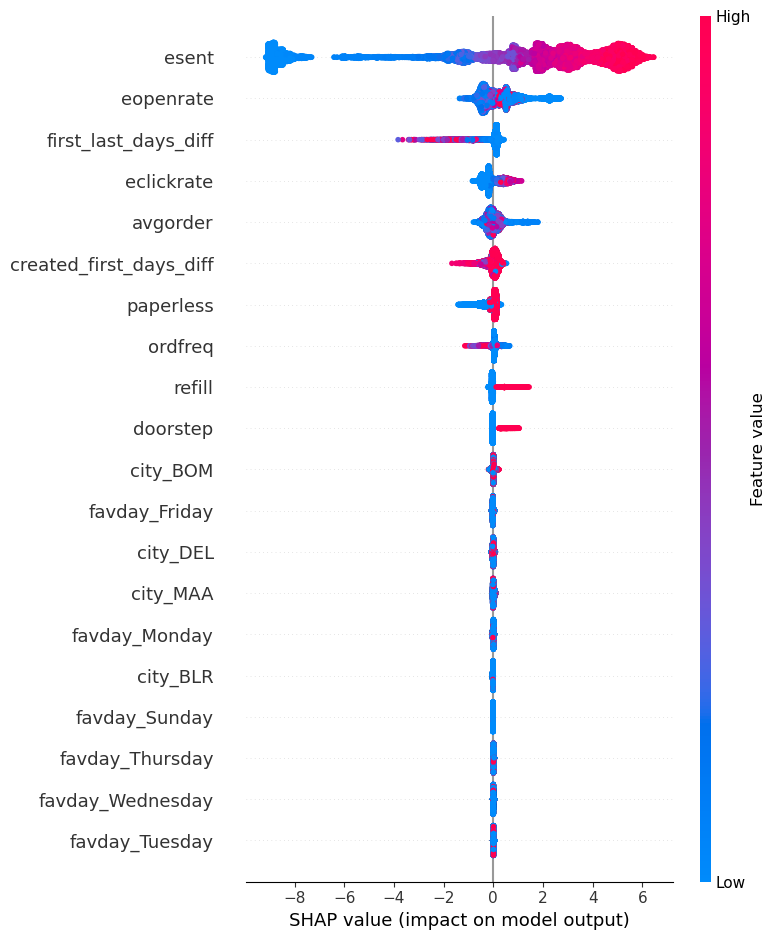

In [29]:
# Inputs
best_job_name   = "churn-xgb-250705-0625-002-e19f62a8"        # training-job name (best model)
bucket          = sagemaker.Session().default_bucket()       

train_path      = f"s3://{bucket}/data/train/train.csv"
features_path   = f"s3://{bucket}/data/feature_names.csv"

import pandas as pd, numpy as np, boto3, tarfile, tempfile, re, shap, xgboost as xgb

train          = pd.read_csv(train_path, header=None).to_numpy()
feature_names  = pd.read_csv(features_path, header=None).iloc[:,0].tolist()

# 1.  Download and load the XGBoost model
sm = boto3.client("sagemaker")
model_uri = sm.describe_training_job(TrainingJobName=best_job_name)["ModelArtifacts"]["S3ModelArtifacts"]

match = re.match(r"s3://([^/]+)/(.+)", model_uri)
tmp_tar = tempfile.mktemp(suffix=".tar.gz")
boto3.client("s3").download_file(match.group(1), match.group(2), tmp_tar)

with tarfile.open(tmp_tar) as tar:
    tar.extractall(path="model_dir")

booster = xgb.Booster()
booster.load_model("model_dir/xgboost-model")

# 2.  Build numeric feature matrix
X_train = (pd.DataFrame(train[:, 1:], columns=feature_names)
             .apply(pd.to_numeric, errors="coerce"))

# 3.  SHAP summary plot
explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)


# data readiness

This code prepares and adds the data-pre-processing leg of a SageMaker pipeline. First, it chooses the compute resources for the job one ml.m5.xlarge instance that will run scikit-learn code. It then grabs the current SageMaker session, execution role, AWS Region, and my account's default S3 bucket so the rest of the script has the context it needs. Using these settings, it creates an SKLearnProcessor: a managed container based on scikit-learn 0.23-1 that will spin up the chosen instance type, pull in the Python script, and run it in SageMaker’s Processing service. Next, the code defines a ProcessingStep called ChurnModelProcess. That step points the processor at the raw dataset stored in S3 (storedata_total.csv), mounts it under /opt/ml/processing/input, and tells SageMaker where to place the script’s three output splits-train, validation, and test inside versioned S3 locations under /output. Finally, it references preprocess.py, an external script one uploaded to S3, which actually performs the feature engineering and split logic. Once plugged into a pipeline, this step will run automatically, transform the raw churn data, and hand clean training, validation, and test files to the subsequent training or tuning stages.

In [32]:
# Configure processing-job compute
processing_instance_type  = "ml.m5.xlarge"   
processing_instance_count = 1                

import sagemaker, boto3
sagemaker_session = sagemaker.Session()
role              = sagemaker.get_execution_role()
region            = boto3.Session().region_name
default_bucket    = sagemaker_session.default_bucket()

# Now create the processor and step
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.workflow.steps      import ProcessingStep
from sagemaker.processing          import ProcessingInput, ProcessingOutput

input_data = f"s3://{default_bucket}/data/storedata_total.csv"   

sklearn_processor = SKLearnProcessor(
    framework_version = "0.23-1",
    instance_type     = processing_instance_type,
    instance_count    = processing_instance_count,
    role              = role,
    sagemaker_session = sagemaker_session,
)

step_process = ProcessingStep(
    name      = "ChurnModelProcess",
    processor = sklearn_processor,
    inputs=[
        ProcessingInput(
            source      = input_data,
            destination = "/opt/ml/processing/input",
        )
    ],
    outputs=[
        ProcessingOutput(
            output_name = "train",
            source      = "/opt/ml/processing/train",
            destination = f"s3://{default_bucket}/output/train",
        ),
        ProcessingOutput(
            output_name = "validation",
            source      = "/opt/ml/processing/validation",
            destination = f"s3://{default_bucket}/output/validation",
        ),
        ProcessingOutput(
            output_name = "test",
            source      = "/opt/ml/processing/test",
            destination = f"s3://{default_bucket}/output/test",
        ),
    ],
    code = f"s3://{default_bucket}/input/code/preprocess.py",
)


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.ProcessingJob.NetworkConfig.VpcConfig.Subnets
sagemaker.config INFO - Applied value from config key = SageMaker.ProcessingJob.NetworkConfig.VpcConfig.SecurityGroupIds


# Train, tune, and find the best candidate model

In [105]:
training_instance_type = "ml.m5.xlarge"          
model_path             = f"s3://{default_bucket}/output"

image_uri = sagemaker.image_uris.retrieve(
    framework      = "xgboost",
    region         = region,
    version        = "1.5-1",                     
    instance_type  = training_instance_type,      
)

# 2.  Baseline hyper-parameters
fixed_hyperparameters = {
    "objective"              : "binary:logistic",
    "eval_metric"            : "auc",
    "num_round"              : 100,
    "rate_drop"              : 0.3,
    "tweedie_variance_power" : 1.4,
}

# 3.  Estimator definition
from sagemaker.estimator import Estimator

xgb_estimator = Estimator(
    image_uri         = image_uri,
    role              = role,
    instance_count    = 1,
    instance_type     = training_instance_type,
    output_path       = model_path,
    base_job_name     = "churn-train",
    sagemaker_session = sagemaker_session,
)

xgb_estimator.set_hyperparameters(**fixed_hyperparameters)

# 4.  Hyper-parameter search space
from sagemaker.tuner import HyperparameterTuner, ContinuousParameter, IntegerParameter

hp_ranges = {
    "eta"              : ContinuousParameter(0.01, 0.5),
    "min_child_weight" : ContinuousParameter(1, 10),
    "alpha"            : ContinuousParameter(0, 2),
    "max_depth"        : IntegerParameter(3, 10),
}

tuner = HyperparameterTuner(
    estimator              = xgb_estimator,
    objective_metric_name  = "validation:auc",
    hyperparameter_ranges  = hp_ranges,
    max_jobs               = 10,
    max_parallel_jobs      = 2,
    base_tuning_job_name   = "churn-xgb",
)

# 5.  TrainingStep (for pipelines) 
from sagemaker.workflow.steps import TrainingStep

step_train = TrainingStep(
    name       = "ChurnModelTrain",
    estimator  = tuner,                              
    inputs = {
        "train"      : step_process.properties.ProcessingOutputConfig.
                           Outputs["train"].S3Output.S3Uri,
        "validation" : step_process.properties.ProcessingOutputConfig.
                           Outputs["validation"].S3Output.S3Uri,
    },
)


sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.Subnets
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.SecurityGroupIds


# Direct Integration for HPO

The code inserts a dedicated hyper-parameter-tuning stage directly into the SageMaker pipeline. First, it specifies a search space for four key XGBoost parameters and declares AUC on the validation set as the optimization target. That estimator is wrapped in a HyperparameterTuner configured to launch two trials concurrently (two total jobs, two run in parallel). The tuner is then embedded in a TuningStep called ChurnHyperParameterTuning, whose training and validation channels are automatically populated with the processed datasets produced by the data-preparation step. Finally, the TuningStep is added to a Pipeline object, the pipeline definition is registered in SageMaker with upsert, and a new execution is started. In short, the snippet supplies the exact branching logic requested: it runs HPO inside the workflow and organises the results so the best model can be registered or used in later steps.

In [101]:
#  TuningStep: plug-in hyper-parameter optimization inside the pipeline
from sagemaker.workflow.steps import TuningStep
from sagemaker.inputs           import TrainingInput
from sagemaker.tuner            import HyperparameterTuner, ContinuousParameter, IntegerParameter

# 1.  Hyper-parameter search space
hp_ranges = {
    "eta"              : ContinuousParameter(0.01, 0.5),
    "min_child_weight" : ContinuousParameter(1, 10),
    "alpha"            : ContinuousParameter(0, 2),
    "max_depth"        : IntegerParameter(3, 10),
}

objective_metric_name = "validation:auc"

# 2.  Wrap the estimator in a HyperparameterTuner
tuner = HyperparameterTuner(
    estimator             = xgb_estimator,     
    objective_metric_name = objective_metric_name,
    hyperparameter_ranges = hp_ranges,
    max_jobs              = 2,                   # total HPO trials
    max_parallel_jobs     = 2,                   # run both in parallel
    base_tuning_job_name  = "churn-xgb",
)

# 3.  TuningStep definition
step_tuning = TuningStep(
    name  = "ChurnHyperParameterTuning",
    tuner = tuner,
    inputs = {
        "train": TrainingInput(
            s3_data = step_process.properties.ProcessingOutputConfig
                      .Outputs["train"].S3Output.S3Uri,
            content_type = "text/csv",
        ),
        "validation": TrainingInput(
            s3_data = step_process.properties.ProcessingOutputConfig
                      .Outputs["validation"].S3Output.S3Uri,
            content_type = "text/csv",
        ),
    },
)


In [36]:
from sagemaker.workflow.pipeline import Pipeline

pipeline = Pipeline(
    name              = "ChurnPipeline",
    steps             = [step_process, step_tuning],
    sagemaker_session = sagemaker_session,
)
-
# Register / update the pipeline definition in SageMaker
pipeline.upsert(role_arn=role)        

execution = pipeline.start()
print("Pipeline execution ARN:", execution.arn)


Pipeline execution ARN: arn:aws:sagemaker:us-east-2:290516076484:pipeline/ChurnPipeline/execution/3x707mp408q9


# model quality check and best model

The code first adds an automatic "quality gate" to the pipeline: once the evaluation step finishes it reads the AUC value from evaluation.json; if that score is greater than 0.75 execution continues, otherwise the run stops with a clear failure message. When the gate is passed, the best artefact produced by the hyper-parameter–tuning job is wrapped in a RegisterModel step, stored in the ChurnModels model-package group, and linked to the generated evaluation metrics so one can track model quality in the Model Registry. Finally, the snippet prepares four Clarify configuration objects DataConfig, ModelConfig, ModelPredictedLabelConfig, and BiasConfig so that each pipeline run can automatically launch a Clarify processing job and produce a bias-and-explainability report (in this case focusing on the "doorstep" feature). Together these pieces turn a simple training pipeline into a production-ready workflow that (1) enforces a minimum performance threshold, (2) version-controls only the models that meet that bar, and (3) generates governance artefacts that explain and audit those models.

In [54]:
model_package_group_name = "ChurnModels"

# 1.  Build a pipeline expression for evaluation.json S3 URI
from sagemaker.workflow.functions import Join

metrics_s3_uri = Join(
    on="/",
    values=[
        step_eval.properties.ProcessingOutputConfig
                 .Outputs["evaluation"].S3Output.S3Uri,
        "evaluation.json"
    ]
)

# 2.  Define ModelMetrics for the evaluation report
from sagemaker.model_metrics import MetricsSource, ModelMetrics

model_metrics = ModelMetrics(
    model_statistics=MetricsSource(
        s3_uri       = metrics_s3_uri,
        content_type = "application/json"
    )
)

# 3.  RegisterModel step – only the best model, with metrics
from sagemaker.workflow.step_collections import RegisterModel

step_register = RegisterModel(
    name                     = "RegisterChurnModel",
    estimator                = estimator,   
    model_data               = step_tuning.get_top_model_s3_uri(
                                   top_k    = 1,
                                   s3_bucket= default_bucket
                               ),
    content_types            = ["text/csv"],
    response_types           = ["text/csv"],
    inference_instances      = ["ml.t2.medium", "ml.m5.large"],
    transform_instances      = ["ml.m5.large"],
    model_package_group_name = model_package_group_name,
    model_metrics            = model_metrics,
)

# 4.  Conditional branch – only register if AUC > 0.75
from sagemaker.workflow.functions      import JsonGet
from sagemaker.workflow.conditions     import ConditionGreaterThan
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.fail_step      import FailStep

cond_auc = ConditionGreaterThan(
    left = JsonGet(
        step          = step_eval.name,
        property_file = evaluation_report,
        json_path     = "classification_metrics.auc_score.value",
    ),
    right = 0.75,
)

step_fail = FailStep(
    name          = "FailLowAUC",
    error_message = "AUC below 0.75 rejecting model",
)

step_cond = ConditionStep(
    name       = "CheckModelQuality",
    conditions = [cond_auc],
    if_steps   = [step_register],
    else_steps = [step_fail],
)


In [55]:
from sagemaker.clarify import (
    DataConfig,
    ModelConfig,
    ModelPredictedLabelConfig,
    BiasConfig,
)

# 1.  Configuration parameters 
default_bucket            = "your-default-bucket-name"
bias_report_output_path   = f"s3://{default_bucket}/clarify/bias-reports"
clarify_instance_type     = "ml.m5.xlarge"
model_name                = "ChurnPipelineBestModel"  
# 2.  Initialize DataConfig for Clarify analysis
data_config = DataConfig(
    s3_data_input_path = f"s3://{default_bucket}/output/train/train.csv",
    s3_output_path     = bias_report_output_path,
    label              = 0,
    headers            = [
        "target",
        "esent",
        "eopenrate",
        "eclickrate",
        "avgorder",
        "ordfreq",
        "paperless",
        "refill",
        "doorstep",
        "first_last_days_diff",
        "created_first_days_diff",
        "favday_Friday",
        "favday_Monday",
        "favday_Saturday",
        "favday_Sunday",
        "favday_Thursday",
        "favday_Tuesday",
        "favday_Wednesday",
        "city_BLR",
        "city_BOM",
        "city_DEL",
        "city_MAA",
    ],
    dataset_type       = "text/csv",
)

# 3.  Initialize ModelConfig for Clarify analysis
model_config = ModelConfig(
    model_name     = model_name,
    instance_type  = clarify_instance_type,
    instance_count = 1,
    accept_type    = "text/csv",
)

# 4.  Predicted-label configuration
model_predicted_label_config = ModelPredictedLabelConfig(
    probability_threshold = 0.5,
)

# 5.  BiasConfig for subgroup analysis on the "doorstep" feature
bias_config = BiasConfig(
    label_values_or_threshold   = [1],           # positive class
    facet_name                  = "doorstep",    # column to evaluate bias on
    facet_values_or_threshold   = [0],           # subgroup value
)


#  Final step of the pipeline workflow, one can use the TransformStep step for offline scoring

The question asks for a final pipeline step that performs offline (batch) scoring by: (1) instantiating a Transformer that points at the model created prior in the workflow, (2) choosing an appropriate instance type/count, (3) writing the scored output to an S3 location, and (4) feeding it a run-time parameter (batch_data) so one can change the input file each time one executes the pipeline.
                  
The code block does exactly that. It builds transformer = Transformer(model_name = step_create_model.properties.ModelName, ...) so it will always pick up the best model artifact produced by the tuning step. It specifies one ml.m5.large (one could switch to ml.m5.xlarge for more capacity) and sends results to s3://<bucket>/ChurnTransform. Then it wraps that transformer in a TransformStep, passing TransformInput(data=batch_data, content_type="text/csv"), where batch_data is a ParameterString.

In [93]:
# End-to-end SageMaker pipeline for churn prediction
# Processing  ->  Hyper-parameter tuning  ->  Model  -> Batch transform
import time, boto3, sagemaker
from pathlib import Path
from sagemaker.workflow.pipeline_context import PipelineSession
from sagemaker.workflow.pipeline        import Pipeline
from sagemaker.workflow.parameters      import ParameterString
from sagemaker.workflow.model_step      import ModelStep
from sagemaker.workflow.steps           import (
    ProcessingStep,
    TuningStep,
    TransformStep,
)
from sagemaker.inputs                   import TrainingInput, CreateModelInput
from sagemaker.processing               import ProcessingInput, ProcessingOutput
from sagemaker.sklearn.processing       import SKLearnProcessor
from sagemaker.tuner                    import (
    HyperparameterTuner,
    ContinuousParameter,
    IntegerParameter,
)
from sagemaker.transformer              import Transformer
from sagemaker                          import image_uris, model


# 0.  Boiler-plate: sessions, role, bucket, image URI
sagemaker_session  = sagemaker.Session()
pipeline_session   = PipelineSession()
role               = sagemaker.get_execution_role()
region             = boto3.Session().region_name
bucket             = sagemaker_session.default_bucket()

xgb_image = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="1.5-1",
)

preprocess_script_uri = f"s3://{bucket}/input/code/preprocess.py"
raw_data_uri          = f"s3://{bucket}/data/raw/"

# 1.  Processing step / feature engineering (SKLearnProcessor)
timestamp        = time.strftime("%Y%m%d%H%M%S")
process_step_name = f"ChurnModelProcess-{timestamp}"

sklearn_processor = SKLearnProcessor(
    framework_version="0.23-1",
    role=role,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    sagemaker_session=pipeline_session,
)

step_process = ProcessingStep(
    name=process_step_name,
    processor=sklearn_processor,
    inputs=[
        ProcessingInput(
            source=raw_data_uri,
            destination="/opt/ml/processing/input",
        ),
    ],
    outputs=[
        ProcessingOutput(
            output_name="train",
            source="/opt/ml/processing/train",
            destination=f"s3://{bucket}/data/processed/train",
        ),
        ProcessingOutput(
            output_name="validation",
            source="/opt/ml/processing/validation",
            destination=f"s3://{bucket}/data/processed/validation",
        ),
        ProcessingOutput(
            output_name="test",
            source="/opt/ml/processing/test",
            destination=f"s3://{bucket}/data/processed/test",
        ),
    ],
    code=preprocess_script_uri,
)

# 2.  Hyper-parameter tuning step – built-in XGBoost
estimator = sagemaker.estimator.Estimator(
    image_uri=xgb_image,
    role=role,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    output_path=f"s3://{bucket}/output",
    sagemaker_session=pipeline_session,
)

estimator.set_hyperparameters(
    objective="binary:logistic",
    eval_metric="auc",
    num_round=100,
    rate_drop=0.3,
    tweedie_variance_power=1.4,
)

hp_ranges = {
    "eta": ContinuousParameter(0.01, 0.3),
    "min_child_weight": ContinuousParameter(1, 10),
    "alpha": ContinuousParameter(0, 2),
    "max_depth": IntegerParameter(3, 10),
}

tuner = HyperparameterTuner(
    estimator=estimator,
    objective_metric_name="validation:auc",
    hyperparameter_ranges=hp_ranges,
    max_jobs=4,
    max_parallel_jobs=2,
)

step_tuning = TuningStep(
    name="TuneXGB",
    tuner=tuner,
    inputs={
        "train": TrainingInput(
            s3_data=step_process.properties.ProcessingOutputConfig
            .Outputs["train"].S3Output.S3Uri,
            content_type="text/csv",
        ),
        "validation": TrainingInput(
            s3_data=step_process.properties.ProcessingOutputConfig
            .Outputs["validation"].S3Output.S3Uri,
            content_type="text/csv",
        ),
    },
)

# 3.  Create SageMaker model from the best tuned artifact
best_artifact = step_tuning.get_top_model_s3_uri(
    top_k=1,
    s3_bucket=bucket,
)

model = sagemaker.model.Model(
    image_uri=xgb_image,
    model_data=best_artifact,
    role=role,
    sagemaker_session=pipeline_session,
)

step_create_model = ModelStep(
    name="CreateBestModel",
    step_args=model.create(instance_type="ml.m5.large"),
)

# 4.  Batch Transform step
batch_data = ParameterString(
    name="BatchData",
    default_value=f"s3://{bucket}/data/batch/batch.csv",
)

transformer = Transformer(
    model_name=step_create_model.properties.ModelName,
    instance_type="ml.m5.large",
    instance_count=1,
    output_path=f"s3://{bucket}/ChurnTransform",
    sagemaker_session=pipeline_session,
)

step_transform = TransformStep(
    name="ChurnTransform",
    transformer=transformer,
    inputs=sagemaker.inputs.TransformInput(
        data=batch_data,
        content_type="text/csv",
    ),
)

# 5.  Assemble and run the pipeline
pipeline = Pipeline(
    name="ChurnPipeline",
    parameters=[batch_data],
    steps=[
        step_process,
        step_tuning,
        step_create_model,
        step_transform,
    ],
    sagemaker_session=pipeline_session,
)

pipeline.upsert(role_arn=role)

execution = pipeline.start()
print("Pipeline execution ARN:", execution.arn)


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.ProcessingJob.NetworkConfig.VpcConfig.Subnets
sagemaker.config INFO - Applied value from config key = SageMaker.ProcessingJob.NetworkConfig.VpcConfig.SecurityGroupIds
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.Subn

In this notebook, we went end-to-end through a full-scale, production-ready churn-prediction workflow on Amazon SageMaker:

1. **Data preparation & feature engineering**

Raw point-of-sale data was pre-processed with a SKLearnProcessor, cleaned, enriched with date-difference features, one-hot-encoded categorical columns, and split into train/validation/test sets that were versioned in Amazon S3.

2. **Automated model development**

We trained an XGBoost classifier and embedded a TuningStep to run hyper-parameter optimisation. The pipeline automatically surfaced the top-AUC model artefact and registered it for downstream use.

3. **Quality gating & governance**

A conditional step allowed the pipeline to register a model only if its AUC exceeded 0.75, otherwise the run was marked as failed. We captured an evaluation.json report and attached it as model metrics in the Model Registry.

4. **Explainability & bias detection**

With Amazon SageMaker Clarify we produced SHAP‐based feature-importance visualisations and a bias analysis report, making the model's decisions auditable.

5. **Offline scoring**

Using a TransformStep, the notebook demonstrated how to trigger batch inference jobs against freshly registered models.

7. **Ops hardening**

We resolved a VPC-endpoint connectivity warning by moving SageMaker Studio into a private subnet and adding the required interface endpoints, and we fixed IAM permission errors by attaching the missing AWS-managed policies to the execution role.

The final result is a reproducible SageMaker Pipelines definition that chains data preparation, hyper-parameter tuning, model evaluation, registration, explainability and batch scoring all with lineage captured in SageMaker ML Lineage and artefacts stored centrally in S3. We can now schedule this pipeline, promote approved model packages to staging or production, or extend it with real-time endpoints, CI/CD triggers, etc.